<a href="https://colab.research.google.com/github/aislam2346/aislam/blob/main/NYC_Taxi_Incremental_Ingestion_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install packages
# !pip install cupy


In [ ]:
# Mount folders
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install packages
import duckdb
import pandas as pd
import requests
import os
import hashlib
from pathlib import Path
from datetime import datetime
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

In [ ]:
# In Colab — download directly from TLC to VM (not Drive)
!wget https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2019-01.parquet

# Process it immediately
import pandas as pd
df = pd.read_parquet("yellow_tripdata_2019-01.parquet")

--2026-03-24 10:49:20--  https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2019-01.parquet
Resolving d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)... 3.169.43.52, 3.169.43.33, 3.169.43.109, ...
Connecting to d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)|3.169.43.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 110439634 (105M) [application/x-www-form-urlencoded]
Saving to: ‘yellow_tripdata_2019-01.parquet’

yellow_tripdata_201 100%[===================>] 105.32M  24.9MB/s    in 5.2s    

2026-03-24 10:49:26 (20.3 MB/s) - ‘yellow_tripdata_2019-01.parquet’ saved [110439634/110439634]



In [ ]:
display(df)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.50,1.0,N,151,239,1,7.00,0.50,0.5,1.65,0.00,0.3,9.95,NaN,None
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.60,1.0,N,239,246,1,14.00,0.50,0.5,1.00,0.00,0.3,16.30,NaN,None
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.00,1.0,N,236,236,1,4.50,0.50,0.5,0.00,0.00,0.3,5.80,NaN,None
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.00,1.0,N,193,193,2,3.50,0.50,0.5,0.00,0.00,0.3,7.55,NaN,None
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.00,2.0,N,193,193,2,52.00,0.00,0.5,0.00,0.00,0.3,55.55,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7696612,2,2019-01-31 23:37:20,2019-02-01 00:10:43,NaN,10.24,NaN,None,142,95,0,0.00,2.75,0.0,0.00,5.76,0.3,0.00,NaN,None
7696613,2,2019-01-31 23:28:00,2019-01-31 23:50:50,NaN,12.43,NaN,None,48,213,0,48.80,5.50,0.0,0.00,0.00,0.3,54.60,NaN,None
7696614,2,2019-01-31 23:11:00,2019-01-31 23:46:00,NaN,9.14,NaN,None,159,246,0,51.05,2.75,0.5,0.00,0.00,0.3,54.60,NaN,None
7696615,2,2019-01-31 23:03:00,2019-01-31 23:14:00,NaN,0.00,NaN,None,265,265,0,0.00,0.00,0.5,9.82,0.00,0.3,0.00,NaN,None


In [ ]:
# Define directories to NYC Taxi datasets and Duck DB database
os.makedirs("/content/drive/MyDrive/ODATA57078/nyc_taxi_data_2019", exist_ok=True)
DB_PATH = "/content/drive/MyDrive/ODATA57078/nyc_taxi_data/taxi.duckdb"
PARQUET_DIR = "/content/drive/MyDrive/ODATA57078/nyc_taxi_data_2019"
ZONE_LOOKUP_PATH = "/content/drive/MyDrive/ODATA57078/taxi_zone_lookup.csv"
OUTPUT_DIR = Path("/content/drive/MyDrive/ODATA57078/eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
def file_checksum(path: Path) -> str:
    """MD5 checksum — used to detect if a source file has been replaced."""
    md5 = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            md5.update(chunk)
    return md5.hexdigest()

In [ ]:
# DuckDB set up

def get_connection(db_path: str = DB_PATH) -> duckdb.DuckDBPyConnection:
    """Open (or create) the persistent DuckDB database."""
    con = duckdb.connect(db_path)
    con.execute("PRAGMA threads=4")          # tune for Colab's 2–4 vCPUs
    con.execute("PRAGMA memory_limit='2GB'") # stay within Colab's RAM
    return con


def bootstrap_schema(con: duckdb.DuckDBPyConnection):
    """
    Create all layers and the watermark / audit tables on first run.
    Idempotent — safe to call on every run.
    """

    # Watermark table — tracks which files have been ingested
    con.execute("""
        CREATE TABLE IF NOT EXISTS pipeline_watermark (
            file_name      VARCHAR PRIMARY KEY,
            file_month     VARCHAR,          -- 'YYYY-MM'
            checksum       VARCHAR,
            row_count      BIGINT,
            ingested_at    TIMESTAMP,
            layer          VARCHAR           -- 'raw' | 'staging' | 'gold'
        )
    """)

    # Raw layer — untouched source data + metadata columns
    con.execute("""
        CREATE TABLE IF NOT EXISTS raw_taxi_trips (
            -- Core trip columns (NYC TLC yellow taxi schema)
            VendorID                INTEGER,
            tpep_pickup_datetime    TIMESTAMP,
            tpep_dropoff_datetime   TIMESTAMP,
            passenger_count         DOUBLE,
            trip_distance           DOUBLE,
            RatecodeID              DOUBLE,
            store_and_fwd_flag      VARCHAR,
            PULocationID            INTEGER,
            DOLocationID            INTEGER,
            payment_type            BIGINT,
            fare_amount             DOUBLE,
            extra                   DOUBLE,
            mta_tax                 DOUBLE,
            tip_amount              DOUBLE,
            tolls_amount            DOUBLE,
            improvement_surcharge   DOUBLE,
            total_amount            DOUBLE,
            congestion_surcharge    DOUBLE,
            airport_fee             DOUBLE,
            -- Pipeline metadata
            file_name               VARCHAR,
            file_month              VARCHAR,
            ingested_at             TIMESTAMP
        )
    """)

    # Staging layer — cleaned, validated data
    con.execute("""
        CREATE TABLE IF NOT EXISTS staging_taxi_trips (
            VendorID                INTEGER,
            tpep_pickup_datetime    TIMESTAMP,
            tpep_dropoff_datetime   TIMESTAMP,
            passenger_count         INTEGER,
            trip_distance           DOUBLE,
            PULocationID            INTEGER,
            DOLocationID            INTEGER,
            payment_type            INTEGER,
            fare_amount             DOUBLE,
            tip_amount              DOUBLE,
            total_amount            DOUBLE,
            trip_duration_mins      DOUBLE,   -- derived
            file_month              VARCHAR,
            ingested_at             TIMESTAMP,
            rowhash                 VARCHAR,  -- Added for deduplication
            congestion_surcharge    DOUBLE    -- Added for specific analysis
        )
    """)

    # Gold layer — analytics-ready, deduplicated
    con.execute("""
        CREATE TABLE IF NOT EXISTS gold_taxi_trips (
            file_month              VARCHAR,
            tpep_pickup_datetime    TIMESTAMP,
            tpep_dropoff_datetime   TIMESTAMP,
            passenger_count         INTEGER,
            trip_distance           DOUBLE,
            PULocationID            INTEGER,
            DOLocationID            INTEGER,
            payment_type            INTEGER,
            fare_amount             DOUBLE,
            tip_amount              DOUBLE,
            total_amount            DOUBLE,
            trip_duration_mins      DOUBLE,
            ingested_at             TIMESTAMP
        )
    """)

    print(" Schema bootstrapped (idempotent)")


In [ ]:
# Define connection
con = get_connection(DB_PATH)

In [ ]:
# Watermark helpers

def is_already_ingested(con: duckdb.DuckDBPyConnection,
                        file_name: str,
                        checksum: str,
                        layer: str) -> bool:
    """
    Returns True if this file+checksum combo has already been loaded
    into the requested layer. If the file exists but the checksum has
    changed (source file was replaced), returns False so it re-ingests.
    """
    result = con.execute("""
        SELECT checksum FROM pipeline_watermark
        WHERE file_name = ? AND layer = ?
    """, [file_name, layer]).fetchone()

    if result is None:
        return False                  # never seen this file
    if result[0] != checksum:
        print(f" Checksum changed for {file_name} — will re-ingest")
        return False
    return True


def mark_ingested(con: duckdb.DuckDBPyConnection,
                  file_name: str,
                  file_month: str,
                  checksum: str,
                  row_count: int,
                  layer: str):
    """Upsert a watermark record after successful ingestion."""
    con.execute("""
        INSERT INTO pipeline_watermark
            (file_name, file_month, checksum, row_count, ingested_at, layer)
        VALUES (?, ?, ?, ?, now(), ?)
        ON CONFLICT (file_name) DO UPDATE SET
            checksum    = excluded.checksum,
            row_count   = excluded.row_count,
            ingested_at = excluded.ingested_at,
            layer       = excluded.layer
    """, [file_name, file_month, checksum, row_count, layer])


# Layer 1 — Raw ingestion

def ingest_raw(con: duckdb.DuckDBPyConnection,
               parquet_path: Path,
               file_month: str):
    """
    Load the parquet file as-is into raw_taxi_trips.
    Adds file_name, file_month and ingested_at metadata columns.
    Skips if already ingested (checksum match).
    """
    file_name = parquet_path.name
    checksum  = file_checksum(parquet_path)

    if is_already_ingested(con, file_name, checksum, layer="raw"):
        print(f" Raw already ingested: {file_name}")
        return

    # Delete any prior rows for this month (handles re-ingestion)
    con.execute("DELETE FROM raw_taxi_trips WHERE file_name = ?", [file_name])

    con.execute(f"""
        INSERT INTO raw_taxi_trips
        SELECT
            VendorID,
            tpep_pickup_datetime,
            tpep_dropoff_datetime,
            passenger_count,
            trip_distance,
            RatecodeID,
            store_and_fwd_flag,
            PULocationID,
            DOLocationID,
            payment_type,
            fare_amount,
            extra,
            mta_tax,
            tip_amount,
            tolls_amount,
            improvement_surcharge,
            total_amount,
            TRY_CAST(congestion_surcharge AS DOUBLE),
            TRY_CAST(airport_fee          AS DOUBLE),
            '{file_name}'  AS file_name,
            '{file_month}' AS file_month,
            now()          AS ingested_at
        FROM read_parquet('{parquet_path}')
    """)

    row_count = con.execute(
        "SELECT COUNT(*) FROM raw_taxi_trips WHERE file_name = ?", [file_name]
    ).fetchone()[0]

    mark_ingested(con, file_name, file_month, checksum, row_count, layer="raw")
    print(f" Raw  | {file_name} | {row_count:,} rows")



In [ ]:
# Step 1 — Schema consistency check
schema_map = {}
for f in sorted(os.listdir(PARQUET_DIR)):
    if f.endswith(".parquet"):
        schema = pq.read_schema(os.path.join(PARQUET_DIR, f))
        schema_map[f] = {name: str(dtype) for name, dtype in zip(schema.names, schema.types)}

all_cols = set(col for s in schema_map.values() for col in s)
for col in sorted(all_cols):
    types_seen = set(s.get(col, "MISSING") for s in schema_map.values())
    if len(types_seen) > 1:
        print(f" Schema inconsistency — {col}: {types_seen}")

# Step 2 — Feed directly into ingest_raw, no pandas loop needed
con = get_connection(DB_PATH)
bootstrap_schema(con)

processed_parquet_files_count = 0
for f in sorted(os.listdir(PARQUET_DIR)):
    if f.endswith(".parquet"):
        processed_parquet_files_count += 1
        if processed_parquet_files_count in range(1,7):
            # Extract month from filename e.g. "yellow_tripdata_2019-03.parquet"
            file_month = f.replace("yellow_tripdata_", "").replace(".parquet", "")
            ingest_raw(con, Path(os.path.join(PARQUET_DIR, f)), file_month)

# con.close()

 Schema bootstrapped (idempotent)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 Raw  | yellow_tripdata_2019-01.parquet | 7,696,617 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 Raw  | yellow_tripdata_2019-02.parquet | 7,049,370 rows


...

 Raw  | yellow_tripdata_2019-04.parquet | 7,475,949 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 Raw  | yellow_tripdata_2019-05.parquet | 7,598,445 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 Raw  | yellow_tripdata_2019-06.parquet | 6,971,560 rows


## Perform preliminary analysis on the ingested data

In [ ]:
# Preview data
previewData = con.execute("""
    SELECT *
    FROM raw_taxi_trips
    LIMIT 10
""")
df_previewData = previewData.fetchdf()
display(df_previewData)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,file_name,file_month,ingested_at
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,...,0.5,1.65,0.00,0.3,9.95,NaN,NaN,yellow_tripdata_2019-01.parquet,2019-01,2026-03-23 21:37:14.675
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,...,0.5,1.00,0.00,0.3,16.30,NaN,NaN,yellow_tripdata_2019-01.parquet,2019-01,2026-03-23 21:37:14.675
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,...,0.5,0.00,0.00,0.3,5.80,NaN,NaN,yellow_tripdata_2019-01.parquet,2019-01,2026-03-23 21:37:14.675
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,...,0.5,0.00,0.00,0.3,7.55,NaN,NaN,yellow_tripdata_2019-01.parquet,2019-01,2026-03-23 21:37:14.675
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,...,0.5,0.00,0.00,0.3,55.55,NaN,NaN,yellow_tripdata_2019-01.parquet,2019-01,2026-03-23 21:37:14.675
5,2,2018-11-28 16:25:49,2018-11-28 16:28:26,5.0,0.0,1.0,N,193,193,2,...,0.5,0.00,5.76,0.3,13.31,NaN,NaN,yellow_tripdata_2019-01.parquet,2019-01,2026-03-23 21:37:14.675
6,2,2018-11-28 16:29:37,2018-11-28 16:33:43,5.0,0.0,2.0,N,193,193,2,...,0.5,0.00,0.00,0.3,55.55,NaN,NaN,yellow_tripdata_2019-01.parquet,2019-01,2026-03-23 21:37:14.675
7,1,2019-01-01 00:21:28,2019-01-01 00:28:37,1.0,1.3,1.0,N,163,229,1,...,0.5,1.25,0.00,0.3,9.05,NaN,NaN,yellow_tripdata_2019-01.parquet,2019-01,2026-03-23 21:37:14.675
8,1,2019-01-01 00:32:01,2019-01-01 00:45:39,1.0,3.7,1.0,N,229,7,1,...,0.5,3.70,0.00,0.3,18.50,NaN,NaN,yellow_tripdata_2019-01.parquet,2019-01,2026-03-23 21:37:14.675
9,1,2019-01-01 00:57:32,2019-01-01 01:09:32,2.0,2.1,1.0,N,141,234,1,...,0.5,1.70,0.00,0.3,13.00,NaN,NaN,yellow_tripdata_2019-01.parquet,2019-01,2026-03-23 21:37:14.675


In [ ]:
# Preview columns and data type
previewColumnDetails = con.execute("""
    SELECT *
    FROM INFORMATION_SCHEMA.COLUMNS
    WHERE table_name = 'raw_taxi_trips'
""")
df_previewColumnDetails = previewColumnDetails.fetchdf()
display(df_previewColumnDetails)

,table_catalog,table_schema,table_name,column_name,ordinal_position,column_default,is_nullable,data_type,character_maximum_length,character_octet_length,...,identity_generation,identity_start,identity_increment,identity_maximum,identity_minimum,identity_cycle,is_generated,generation_expression,is_updatable,COLUMN_COMMENT
0,taxi,main,raw_taxi_trips,VendorID,1,None,YES,INTEGER,<NA>,<NA>,...,None,None,None,None,None,<NA>,None,None,<NA>,None
1,taxi,main,raw_taxi_trips,tpep_pickup_datetime,2,None,YES,TIMESTAMP,<NA>,<NA>,...,None,None,None,None,None,<NA>,None,None,<NA>,None
2,taxi,main,raw_taxi_trips,tpep_dropoff_datetime,3,None,YES,TIMESTAMP,<NA>,<NA>,...,None,None,None,None,None,<NA>,None,None,<NA>,None
3,taxi,main,raw_taxi_trips,passenger_count,4,None,YES,DOUBLE,<NA>,<NA>,...,None,None,None,None,None,<NA>,None,None,<NA>,None
4,taxi,main,raw_taxi_trips,trip_distance,5,None,YES,DOUBLE,<NA>,<NA>,...,None,None,None,None,None,<NA>,None,None,<NA>,None
5,taxi,main,raw_taxi_trips,RatecodeID,6,None,YES,DOUBLE,<NA>,<NA>,...,None,None,None,None,None,<NA>,None,None,<NA>,None
6,taxi,main,raw_taxi_trips,store_and_fwd_flag,7,None,YES,VARCHAR,<NA>,<NA>,...,None,None,None,None,None,<NA>,None,None,<NA>,None
7,taxi,main,raw_taxi_trips,PULocationID,8,None,YES,INTEGER,<NA>,<NA>,...,None,None,None,None,None,<NA>,None,None,<NA>,None
8,taxi,main,raw_taxi_trips,DOLocationID,9,None,YES,INTEGER,<NA>,<NA>,...,None,None,None,None,None,<NA>,None,None,<NA>,None
9,taxi,main,raw_taxi_trips,payment_type,10,None,YES,BIGINT,<NA>,<NA>,...,None,None,None,None,None,<NA>,None,None,<NA>,None


In [ ]:
# Validate distinct number of values for the columns
distinctValues = con.execute("""
  SELECT 'SELECT ' || STRING_AGG(
    'COUNT(DISTINCT "' || column_name || '") AS "' || column_name || '_distinct_count"', ', '
  ) || ' FROM raw_taxi_trips' AS query_to_execute
  FROM information_schema.columns
  WHERE table_name = 'raw_taxi_trips' AND table_schema = 'main';
""")
distinctValues

df_distinctValues = distinctValues.fetchdf()
display(df_distinctValues)

,query_to_execute
0,"SELECT COUNT(DISTINCT ""VendorID"") AS ""VendorID..."


In [ ]:
sql_query_to_execute = df_distinctValues.loc[0, 'query_to_execute']

# Execute the dynamically generated query
df_distinct_counts = con.execute(sql_query_to_execute).fetchdf()
display(df_distinct_counts)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,VendorID_distinct_count,tpep_pickup_datetime_distinct_count,tpep_dropoff_datetime_distinct_count,passenger_count_distinct_count,trip_distance_distinct_count,RatecodeID_distinct_count,store_and_fwd_flag_distinct_count,PULocationID_distinct_count,DOLocationID_distinct_count,payment_type_distinct_count,...,mta_tax_distinct_count,tip_amount_distinct_count,tolls_amount_distinct_count,improvement_surcharge_distinct_count,total_amount_distinct_count,congestion_surcharge_distinct_count,airport_fee_distinct_count,file_name_distinct_count,file_month_distinct_count,ingested_at_distinct_count
0,4,13170924,13183930,10,6278,7,2,263,263,6,...,36,5787,2454,5,20452,12,0,6,6,6


1. We want to know what data quality issues currently exist in the ingested dataset.



In [ ]:
# Check row counts
countRows = con.execute("""
    SELECT
        file_month,
        COUNT(*) AS total_rows
    FROM raw_taxi_trips
    GROUP BY file_month
    ORDER BY file_month
""")
countRows

In [ ]:
df_countRows = countRows.fetchdf()
display(df_countRows)

,file_month,total_rows
0,2019-01,7696617
1,2019-02,7049370
2,2019-03,7866620
3,2019-04,7475949
4,2019-05,7598445
5,2019-06,6971560


In [ ]:
# Identify null values

nullCount = con.execute("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(*) - COUNT(tpep_pickup_datetime)  AS null_pickup,
        COUNT(*) - COUNT(tpep_dropoff_datetime) AS null_dropoff,
        COUNT(*) - COUNT(passenger_count)       AS null_passengers,
        COUNT(*) - COUNT(trip_distance)         AS null_distance,
        COUNT(*) - COUNT(fare_amount)           AS null_fare,
        COUNT(*) - COUNT(total_amount)          AS null_total,
        COUNT(*) - COUNT(PULocationID)          AS null_pickup_loc,
        COUNT(*) - COUNT(DOLocationID)          AS null_dropoff_loc,
        COUNT(*) - COUNT(congestion_surcharge)  AS null_congestion
    FROM raw_taxi_trips
""")

df_nullCount = nullCount.fetchdf()
display(df_nullCount)

,total_rows,null_pickup,null_dropoff,null_passengers,null_distance,null_fare,null_total,null_pickup_loc,null_dropoff_loc,null_congestion
0,44658561,0,0,197782,0,0,0,0,0,5053997


In [ ]:
# Identify unusual values

outOfRangeValues = con.execute("""
       SELECT
        file_month,
        -- Fare issues
        SUM(CASE WHEN fare_amount <= 0     THEN 1 ELSE 0 END) AS negative_or_zero_fare,
        SUM(CASE WHEN total_amount <= 0    THEN 1 ELSE 0 END) AS negative_total,
        SUM(CASE WHEN fare_amount > 500    THEN 1 ELSE 0 END) AS extreme_fare,
        -- Distance issues
        SUM(CASE WHEN trip_distance <= 0   THEN 1 ELSE 0 END) AS zero_distance,
        SUM(CASE WHEN trip_distance > 100  THEN 1 ELSE 0 END) AS extreme_distance,
        -- Passenger issues
        SUM(CASE WHEN passenger_count < 1  THEN 1 ELSE 0 END) AS zero_passengers,
        SUM(CASE WHEN passenger_count > 6  THEN 1 ELSE 0 END) AS too_many_passengers,
        -- Timestamp issues
        SUM(CASE WHEN tpep_dropoff_datetime <= tpep_pickup_datetime THEN 1 ELSE 0 END) AS invalid_timestamps,
        COUNT(*) AS total_rows
    FROM raw_taxi_trips
    GROUP BY file_month
    ORDER BY file_month
""")

df_outOfRangeValues = outOfRangeValues.fetchdf()
display(df_outOfRangeValues)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,file_month,negative_or_zero_fare,negative_total,extreme_fare,zero_distance,extreme_distance,zero_passengers,too_many_passengers,invalid_timestamps,total_rows
0,2019-01,9770.0,8770.0,34.0,55089.0,32.0,117381.0,57.0,6557.0,7696617
1,2019-02,12344.0,11252.0,12.0,49784.0,17.0,119150.0,72.0,6395.0,7049370
2,2019-03,14791.0,13577.0,19.0,53819.0,24.0,140131.0,82.0,6242.0,7866620
3,2019-04,14847.0,13593.0,18.0,50966.0,32.0,136807.0,72.0,6254.0,7475949
4,2019-05,16587.0,15365.0,28.0,56354.0,23.0,143805.0,79.0,7682.0,7598445
5,2019-06,17150.0,15953.0,24.0,63075.0,38.0,128130.0,91.0,8994.0,6971560


In [ ]:
# Analyse trip duration distribution to see what outliers look like

tripDurationDistribution = con.execute("""
  SELECT
      file_month,
      MIN(DATEDIFF('minute', tpep_pickup_datetime, tpep_dropoff_datetime)) AS min_duration_mins,
      MAX(DATEDIFF('minute', tpep_pickup_datetime, tpep_dropoff_datetime)) AS max_duration_mins,
      AVG(DATEDIFF('minute', tpep_pickup_datetime, tpep_dropoff_datetime)) AS avg_duration_mins,
      PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY DATEDIFF('minute', tpep_pickup_datetime, tpep_dropoff_datetime)) AS p25,
      PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY DATEDIFF('minute', tpep_pickup_datetime, tpep_dropoff_datetime)) AS p50,
      PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY DATEDIFF('minute', tpep_pickup_datetime, tpep_dropoff_datetime)) AS p95
  FROM raw_taxi_trips
  GROUP BY file_month
  ORDER BY file_month
""")

df_tripDurationDistribution = tripDurationDistribution.fetchdf()
display(df_tripDurationDistribution)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,file_month,min_duration_mins,max_duration_mins,avg_duration_mins,p25,p50,p95
0,2019-01,-84281,43648,16.551099,6.0,10.0,33.0
1,2019-02,-525461,25988,17.214601,6.0,11.0,35.0
2,2019-03,-4139,27454,17.729778,7.0,11.0,37.0
3,2019-04,-54,4518,17.940130,7.0,11.0,38.0
4,2019-05,-368615,8403,18.511917,7.0,12.0,40.0
5,2019-06,-4279,3586,18.786663,7.0,12.0,41.0


In [ ]:
# Analyse trip distance distribution to see what outliers look like

tripDistanceDistribution = con.execute("""
  SELECT
      file_month,
      MIN(trip_distance) AS min_trip_distance,
      MAX(trip_distance) AS max_trip_distance,
      PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY trip_distance) AS p25,
      PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY trip_distance) AS p50,
      PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY trip_distance) AS p95
  FROM raw_taxi_trips
  GROUP BY file_month
  ORDER BY file_month
""")

df_tripDistanceDistribution = tripDistanceDistribution.fetchdf()
display(df_tripDistanceDistribution)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,file_month,min_trip_distance,max_trip_distance,p25,p50,p95
0,2019-01,0.0,831.80,0.90,1.53,10.72
1,2019-02,0.0,701.50,0.94,1.60,10.97
2,2019-03,0.0,237.17,0.98,1.62,11.41
3,2019-04,0.0,830.90,1.00,1.66,11.45
4,2019-05,0.0,401.40,1.00,1.66,11.60
5,2019-06,0.0,45977.22,1.00,1.69,11.78


In [ ]:
checkDuplicates = con.execute("""
      SELECT COUNT(*) AS duplicate_rows
    FROM (
        SELECT
            tpep_pickup_datetime,
            tpep_dropoff_datetime,
            PULocationID,
            DOLocationID,
            total_amount,
            COUNT(*) AS cnt
        FROM raw_taxi_trips
        GROUP BY ALL
        HAVING COUNT(*) > 1
    )
""")

df_checkDuplicates = checkDuplicates.fetchdf()
display(df_checkDuplicates)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_rows
0,1820


In [ ]:
# I want to inspect what the rows with unusual values (missing, invalid values etc.) look like

# 1. Rows with missing passenger count
# Findings - There are missing passenger counts whenever there are missing RatecodeID
# and vice versa

viewEntriesWithMissingPassengerCount = con.execute("""
    SELECT *
    FROM raw_taxi_trips
    WHERE passenger_count IS NULL
    AND RatecodeID IS NOT NULL;
""")

df_viewEntriesWithMissingPassengerCount = viewEntriesWithMissingPassengerCount.fetchdf()
display(df_viewEntriesWithMissingPassengerCount)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,file_name,file_month,ingested_at


In [ ]:
# I want to inspect what the rows with invalid fares

# 1. Rows with missing passenger count
# Findings - There are missing passenger counts whenever there are missing RatecodeID
# and vice versa

viewEntriesWithMissingPassengerCount = con.execute("""
    SELECT *
    FROM raw_taxi_trips
    WHERE passenger_count IS NULL
    AND RatecodeID IS NOT NULL;
""")

df_viewEntriesWithMissingPassengerCount = viewEntriesWithMissingPassengerCount.fetchdf()
display(df_viewEntriesWithMissingPassengerCount)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,file_name,file_month,ingested_at


## Transfer cleaned data into staging table

In [ ]:
# ── Step 1: Derive valid year range dynamically from raw ──────────────────────
# Rather than hardcoding 2019, we infer the expected year from the majority
# of pickup timestamps. This makes the pipeline reusable for other years.

year_range = con.execute("""
    SELECT
        MODE(YEAR(tpep_pickup_datetime))  AS modal_pickup_year,
        MODE(YEAR(tpep_dropoff_datetime)) AS modal_dropoff_year
    FROM raw_taxi_trips
""").fetchdf()

valid_pickup_year  = int(year_range['modal_pickup_year'].iloc[0])
valid_dropoff_year = int(year_range['modal_dropoff_year'].iloc[0])

print(f"  Inferred valid pickup year:  {valid_pickup_year}")
print(f"  Inferred valid dropoff year: {valid_dropoff_year}")


  Inferred valid pickup year:  2019
  Inferred valid dropoff year: 2019


In [ ]:
# Step 2: Preview each cleaning rule BEFORE deleting anything ───────────────
# This the audit log — numbers are to be documented in report.

print("\n── Pre-cleaning audit (raw_taxi_trips) ──────────────────────────────────")

df_audit = con.execute(f"""
    SELECT
        file_month,
        COUNT(*)                                                        AS total_rows,

        -- Rule 1: Invalid timestamps
        SUM(CASE WHEN tpep_pickup_datetime IS NULL
                   OR tpep_dropoff_datetime IS NULL                     THEN 1 ELSE 0 END) AS null_timestamps,
        SUM(CASE WHEN tpep_pickup_datetime >= tpep_dropoff_datetime     THEN 1 ELSE 0 END) AS pickup_gte_dropoff,
        SUM(CASE WHEN YEAR(tpep_pickup_datetime)  != {valid_pickup_year}
                   OR YEAR(tpep_dropoff_datetime) != {valid_dropoff_year} THEN 1 ELSE 0 END) AS out_of_scope_year,

        -- Rule 2: Invalid passenger counts
        SUM(CASE WHEN passenger_count IS NULL                           THEN 1 ELSE 0 END) AS null_passengers,
        SUM(CASE WHEN passenger_count = 0                               THEN 1 ELSE 0 END) AS zero_passengers,
        SUM(CASE WHEN passenger_count > 6                               THEN 1 ELSE 0 END) AS too_many_passengers,

        -- Rule 3: Invalid fares
        SUM(CASE WHEN fare_amount < 2.50                                THEN 1 ELSE 0 END) AS fare_below_minimum,
        SUM(CASE WHEN fare_amount IS NULL                               THEN 1 ELSE 0 END) AS null_fare,
        SUM(CASE WHEN total_amount <= 0                                 THEN 1 ELSE 0 END) AS zero_or_negative_total,
        SUM(CASE WHEN total_amount IS NULL                              THEN 1 ELSE 0 END) AS null_total

    FROM raw_taxi_trips
    GROUP BY file_month
    ORDER BY file_month
""").fetchdf()

display(df_audit)


── Pre-cleaning audit (raw_taxi_trips) ──────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,file_month,total_rows,null_timestamps,pickup_gte_dropoff,out_of_scope_year,null_passengers,zero_passengers,too_many_passengers,fare_below_minimum,null_fare,zero_or_negative_total,null_total
0,2019-01,7696617,0.0,6557.0,445.0,28672.0,117381.0,57.0,10866.0,0.0,8770.0,0.0
1,2019-02,7049370,0.0,6395.0,88.0,29663.0,119150.0,72.0,13580.0,0.0,11252.0,0.0
2,2019-03,7866620,0.0,6242.0,49.0,33474.0,140131.0,82.0,15904.0,0.0,13577.0,0.0
3,2019-04,7475949,0.0,6254.0,70.0,42456.0,136807.0,72.0,16091.0,0.0,13593.0,0.0
4,2019-05,7598445,0.0,7682.0,43.0,32770.0,143805.0,79.0,17815.0,0.0,15365.0,0.0
5,2019-06,6971560,0.0,8994.0,51.0,30747.0,128130.0,91.0,18284.0,0.0,15953.0,0.0


In [ ]:
# ── Step 3: Count total rows affected (with overlap accounted for) ────────────
# Important: a single bad row may violate multiple rules above.
# This query counts DISTINCT bad rows so the true drop count is known.

df_overlap = con.execute(f"""
    SELECT
        file_month,
        COUNT(*) AS rows_to_drop
    FROM raw_taxi_trips
    WHERE
        -- Rule 1: Timestamp issues
        tpep_pickup_datetime IS NULL
        OR tpep_dropoff_datetime IS NULL
        OR tpep_pickup_datetime >= tpep_dropoff_datetime
        OR YEAR(tpep_pickup_datetime)  != {valid_pickup_year}
        OR YEAR(tpep_dropoff_datetime) != {valid_dropoff_year}

        -- Rule 2: Passenger count issues
        OR passenger_count IS NULL
        OR passenger_count = 0
        OR passenger_count > 6

        -- Rule 3: Fare issues
        OR fare_amount IS NULL
        OR fare_amount < 2.50
        OR total_amount IS NULL
        OR total_amount <= 0
    GROUP BY file_month
    ORDER BY file_month
""").fetchdf()

print("\n── Rows to drop per month (accounting for overlap) ──────────────────────")
display(df_overlap)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


── Rows to drop per month (accounting for overlap) ──────────────────────


,file_month,rows_to_drop
0,2019-01,162741
1,2019-02,167693
2,2019-03,194670
3,2019-04,200593
4,2019-05,201031
5,2019-06,185010


In [ ]:
# ── Step 4: Populate staging_raw_trips from raw (insert clean rows only) ───────
# We INSERT the inverse of the bad-row filter rather than DELETE from raw.
# This keeps raw completely untouched.

print("\n── Populating staging_taxi_trips ───────────────────────────────")

con.execute(f"""DELETE FROM staging_taxi_trips;""")  # clear staging if re-running

con.execute(f"""
    INSERT INTO staging_taxi_trips (
        VendorID,
        tpep_pickup_datetime,
        tpep_dropoff_datetime,
        passenger_count,
        trip_distance,
        PULocationID,
        DOLocationID,
        payment_type,
        fare_amount,
        tip_amount,
        total_amount,
        trip_duration_mins,
        file_month,
        ingested_at,
        rowhash,
        congestion_surcharge
    )
    SELECT
        VendorID,
        tpep_pickup_datetime,
        tpep_dropoff_datetime,
        CAST(passenger_count AS INTEGER)    AS passenger_count,
        trip_distance,
        PULocationID,
        DOLocationID,
        CAST(payment_type AS INTEGER)       AS payment_type,
        fare_amount,
        tip_amount,
        total_amount,
        DATEDIFF('minute',
            tpep_pickup_datetime,
            tpep_dropoff_datetime)          AS trip_duration_mins,
        file_month,
        ingested_at,
        md5(
            COALESCE(CAST(tpep_pickup_datetime AS VARCHAR), '') ||
            COALESCE(CAST(tpep_dropoff_datetime AS VARCHAR), '') ||
            COALESCE(CAST(PULocationID AS VARCHAR), '')          ||
            COALESCE(CAST(DOLocationID AS VARCHAR), '')          ||
            COALESCE(CAST(fare_amount AS VARCHAR), '')           ||
            COALESCE(CAST(total_amount AS VARCHAR), '')
        ) AS rowhash,
        congestion_surcharge
    FROM raw_taxi_trips
    WHERE
        -- Rule 1: Keep only valid timestamps
        tpep_pickup_datetime  IS NOT NULL
        AND tpep_dropoff_datetime IS NOT NULL
        AND tpep_pickup_datetime < tpep_dropoff_datetime
        AND YEAR(tpep_pickup_datetime)  = {valid_pickup_year}
        AND YEAR(tpep_dropoff_datetime) = {valid_dropoff_year}

        -- Rule 2: Keep only valid passenger counts
        AND passenger_count IS NOT NULL
        AND passenger_count >= 1
        AND passenger_count <= 6

        -- Rule 3: Keep only valid fares
        AND fare_amount  IS NOT NULL
        AND fare_amount  >= 2.50
        AND total_amount IS NOT NULL
        AND total_amount >  0
""")

con.execute("CHECKPOINT")


── Populating staging_taxi_trips ───────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
print("\n── Sense check ──────────────────────────────────────────────────────────")

df_sense = con.execute(f"""
  SELECT
      s.file_month,
      r.total_raw                                         AS raw_rows,
      COUNT(*)                                            AS staging_rows,
      r.total_raw - COUNT(*)                              AS rows_dropped,
      ROUND(100.0 * (r.total_raw - COUNT(*))
            / r.total_raw, 2)                            AS pct_dropped,

      -- Verify no bad rows survived cleaning
      SUM(CASE WHEN s.fare_amount < 2.50          THEN 1 ELSE 0 END) AS bad_fare_remaining,
      SUM(CASE WHEN s.passenger_count < 1
                OR s.passenger_count > 6         THEN 1 ELSE 0 END) AS bad_passengers_remaining,
      SUM(CASE WHEN s.total_amount <= 0           THEN 1 ELSE 0 END) AS bad_total_remaining,
      SUM(CASE WHEN s.tpep_pickup_datetime
                  >= s.tpep_dropoff_datetime      THEN 1 ELSE 0 END) AS bad_timestamps_remaining,

      -- Check there are no duplicates in the dataset
      -- using row hash
      (COUNT(s.rowhash) - COUNT(DISTINCT s.rowhash)) AS duplicate_rows

  FROM staging_taxi_trips s
  JOIN (
      SELECT file_month, COUNT(*) AS total_raw
      FROM raw_taxi_trips
      GROUP BY file_month
  ) r ON s.file_month = r.file_month
  GROUP BY s.file_month, r.total_raw
  ORDER BY s.file_month
""").fetchdf()

display(df_sense)

# Final confirmation
bad_remaining = df_sense[["bad_fare_remaining",
                           "bad_passengers_remaining",
                           "bad_total_remaining",
                           "bad_timestamps_remaining"]].sum().sum()

if bad_remaining == 0:
    print("\n  All cleaning rules passed — no bad rows in staging.")
else:
    print(f"\n  {int(bad_remaining):,} bad rows still present — review cleaning logic.")


── Sense check ──────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,file_month,raw_rows,staging_rows,rows_dropped,pct_dropped,bad_fare_remaining,bad_passengers_remaining,bad_total_remaining,bad_timestamps_remaining,duplicate_rows
0,2019-01,7696617,7533876,162741,2.11,0.0,0.0,0.0,0.0,2
1,2019-02,7049370,6881677,167693,2.38,0.0,0.0,0.0,0.0,52
2,2019-03,7866620,7671950,194670,2.47,0.0,0.0,0.0,0.0,2
3,2019-04,7475949,7275356,200593,2.68,0.0,0.0,0.0,0.0,2
4,2019-05,7598445,7397414,201031,2.65,0.0,0.0,0.0,0.0,6
5,2019-06,6971560,6786550,185010,2.65,0.0,0.0,0.0,0.0,2



  All cleaning rules passed — no bad rows in staging.


## Exploratory Data Analysis

We will be exploring a few ideas
1. What does the distribution of taxi distance and duration look like?
2. What does the trend look like for each time interval e.g. hour of day, weekend, weekday, individual times (morning,afternoon, evening, night), monthly?
3. What is the trend of taxi demand in different boroughs. Here the taxi zone csv file will need to be integrated.
4. We will also explore the effects of weather data on taxi demand. We will include features such as precipation, snow, rain, fog and temperature to the dataset.

In [ ]:
# Preview staging table
previewStagingTable = con.execute("""
    SELECT *
    FROM staging_taxi_trips
    LIMIT 10
""")

df_previewStagingTable = previewStagingTable.fetchdf()
display(df_previewStagingTable)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,total_amount,trip_duration_mins,file_month,ingested_at,rowhash,congestion_surcharge
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1,1.5,151,239,1,7.0,1.65,9.95,7.0,2019-01,2026-03-23 21:37:14.675,b810556cf858ab9876d5a2d91aba0412,NaN
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1,2.6,239,246,1,14.0,1.00,16.30,19.0,2019-01,2026-03-23 21:37:14.675,bdfeb649d2d45efc402bc8c405503d61,NaN
2,1,2019-01-01 00:21:28,2019-01-01 00:28:37,1,1.3,163,229,1,6.5,1.25,9.05,7.0,2019-01,2026-03-23 21:37:14.675,f1f8446576e9bf0d237cfd2ccc4facf6,NaN
3,1,2019-01-01 00:32:01,2019-01-01 00:45:39,1,3.7,229,7,1,13.5,3.70,18.50,13.0,2019-01,2026-03-23 21:37:14.675,5e1928fca69b5c1823a603e7b5e44839,NaN
4,1,2019-01-01 00:57:32,2019-01-01 01:09:32,2,2.1,141,234,1,10.0,1.70,13.00,12.0,2019-01,2026-03-23 21:37:14.675,819612b5bf8c7b3471adcb7cc925c335,NaN
5,1,2019-01-01 00:24:04,2019-01-01 00:47:06,2,2.8,246,162,1,15.0,3.25,19.55,23.0,2019-01,2026-03-23 21:37:14.675,812ec9a84a0b5b1483583236bc3788d5,NaN
6,1,2019-01-01 00:21:59,2019-01-01 00:28:24,1,0.7,238,151,1,5.5,1.70,8.50,7.0,2019-01,2026-03-23 21:37:14.675,ace4c9e9f6df0614fd30b4736f7cb109,NaN
7,1,2019-01-01 00:45:21,2019-01-01 01:31:05,1,8.7,163,25,1,34.5,7.15,42.95,46.0,2019-01,2026-03-23 21:37:14.675,49f8d05c9e12f63b64f709dc7066b286,NaN
8,1,2019-01-01 00:43:19,2019-01-01 01:07:42,1,6.3,224,25,1,21.5,5.70,28.50,24.0,2019-01,2026-03-23 21:37:14.675,47e093ad2ea127729025524646a3a0fb,NaN
9,1,2019-01-01 00:58:24,2019-01-01 01:15:18,1,2.7,141,234,1,13.0,1.00,15.30,17.0,2019-01,2026-03-23 21:37:14.675,89518483b489c8c05419a56b71a9ec26,NaN


In [ ]:
# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 11,
                     "axes.labelsize": 9, "figure.facecolor": "#0f0f1a",
                     "axes.facecolor": "#1a1a2e", "text.color": "white",
                     "axes.labelcolor": "white", "xtick.color": "#aaaaaa",
                     "ytick.color": "#aaaaaa"})


── Section 1: Distance & Duration Distributions ────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/tmp/ipykernel_27152/4249683792.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_month, labels=months, patch_artist=True,
/tmp/ipykernel_27152/4249683792.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(data_by_month_dur, labels=months, patch_artist=True,


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

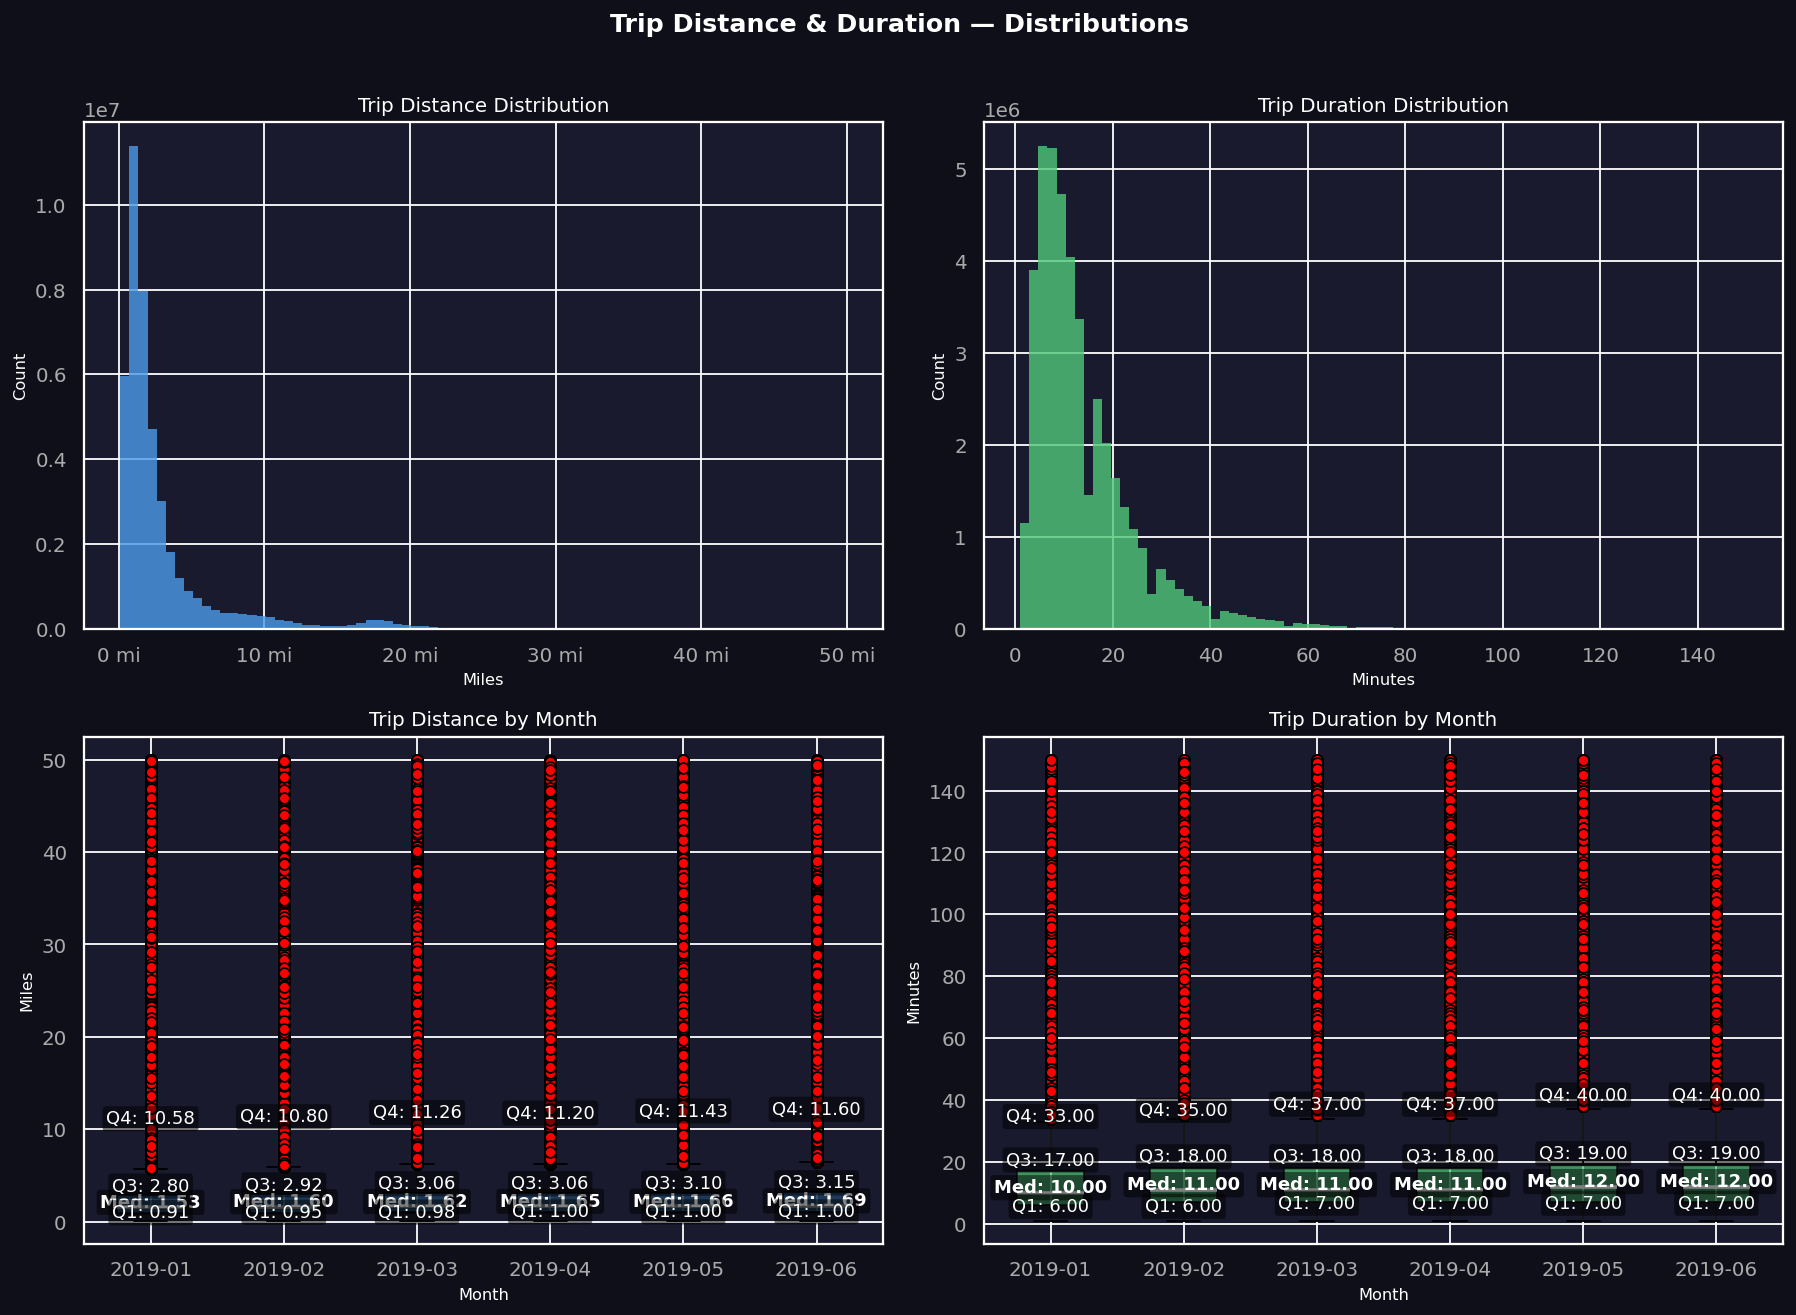

 Saved: 01_distance_duration_distributions.png

  Distance & Duration summary stats:


,file_month,avg_distance_miles,p25_distance,median_distance,p75_distance,p95_distance,avg_duration_mins,p25_duration,median_duration,p75_duration,p95_duration
0,2019-01,2.81,0.91,1.53,2.80,10.58,16.57,6.0,10.0,17.0,33.0
1,2019-02,2.89,0.95,1.60,2.92,10.80,17.30,6.0,11.0,18.0,35.0
2,2019-03,3.00,0.98,1.62,3.06,11.26,17.74,7.0,11.0,18.0,37.0
3,2019-04,3.01,1.00,1.65,3.06,11.20,17.94,7.0,11.0,18.0,37.0
4,2019-05,3.04,1.00,1.66,3.10,11.43,18.60,7.0,12.0,19.0,40.0
5,2019-06,3.08,1.00,1.69,3.15,11.60,18.83,7.0,12.0,19.0,40.0


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — Distribution of trip distance and duration
# ══════════════════════════════════════════════════════════════════════════════
# Why: Understanding the shape of these distributions informs whether
# extreme values are genuine trips or data quality remnants. It also
# provides baseline distributions for drift analysis later.

print("── Section 1: Distance & Duration Distributions ────────────────────────")

df_dist = con.execute("""
    SELECT
        trip_distance,
        trip_duration_mins,
        file_month
    FROM staging_taxi_trips
    -- These thresholds will not exclude too many values
    -- thus ensuring information is not lost when drift analysis is performed.
    -- 50 miles is typically the max distance between NYC
    -- Depending on traffic it can take up to 2.5-3 hours
    WHERE trip_distance      BETWEEN 0.1 AND 50
    AND trip_duration_mins BETWEEN 1   AND 150
""").fetchdf()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Trip Distance & Duration — Distributions", fontsize=14,
             fontweight="bold", color="white", y=1.01)

# Distance histogram
ax = axes[0, 0]
ax.hist(df_dist["trip_distance"], bins=80, color="#4C9BE8", alpha=0.8, edgecolor="none")
ax.set_title("Trip Distance Distribution")
ax.set_xlabel("Miles")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f mi"))

# Duration histogram
ax = axes[0, 1]
ax.hist(df_dist["trip_duration_mins"], bins=80, color="#50C878", alpha=0.8, edgecolor="none")
ax.set_title("Trip Duration Distribution")
ax.set_xlabel("Minutes")
ax.set_ylabel("Count")

# Distance boxplot by month
ax = axes[1, 0]
months = sorted(df_dist["file_month"].unique())
data_by_month = [df_dist[df_dist["file_month"] == m]["trip_distance"].values for m in months]
flierprops = dict(marker='o', markerfacecolor='red', markeredgecolor='black', markersize=6)
bp = ax.boxplot(data_by_month, labels=months, patch_artist=True,
                medianprops=dict(color="white", linewidth=2),flierprops=flierprops)
for patch in bp["boxes"]:
    patch.set_facecolor("#4C9BE8")
    patch.set_alpha(0.7)
ax.set_title("Trip Distance by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Miles")

# Duration boxplot by month
ax = axes[1, 1]
data_by_month_dur = [df_dist[df_dist["file_month"] == m]["trip_duration_mins"].values for m in months]
bp2 = ax.boxplot(data_by_month_dur, labels=months, patch_artist=True,
                 medianprops=dict(color="white", linewidth=2), flierprops = flierprops)
for patch in bp2["boxes"]:
    patch.set_facecolor("#50C878")
    patch.set_alpha(0.7)
ax.set_title("Trip Duration by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Minutes")


# Summary statistics — document these in your proposal
df_stats = con.execute("""
    SELECT
        file_month,
        ROUND(AVG(trip_distance), 2)                                            AS avg_distance_miles,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP
              (ORDER BY trip_distance), 2)                                      AS p25_distance,
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP
              (ORDER BY trip_distance), 2)                                      AS median_distance,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP
              (ORDER BY trip_distance), 2)                                      AS p75_distance,
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP
              (ORDER BY trip_distance), 2)                                      AS p95_distance,
        ROUND(AVG(trip_duration_mins), 2)                                       AS avg_duration_mins,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP
              (ORDER BY trip_duration_mins), 2)                                 AS p25_duration,
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP
              (ORDER BY trip_duration_mins), 2)                                 AS median_duration,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP
              (ORDER BY trip_duration_mins), 2)                                 AS p75_duration,
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP
              (ORDER BY trip_duration_mins), 2)                                      AS p95_duration
    FROM staging_taxi_trips
    GROUP BY file_month
    ORDER BY file_month
""").fetchdf()

# Annotate Distance Boxplot with median, Q1, Q3
ax = axes[1, 0]
for i, month in enumerate(months):
    stats = df_stats[df_stats["file_month"] == month].iloc[0]
    median_val = stats["median_distance"]
    p25_val = stats["p25_distance"]
    p75_val = stats["p75_distance"]
    p95_val = stats["p95_distance"]

    ax.text(i + 1, median_val, f'Med: {median_val:.2f}',
            horizontalalignment='center', size='small', color='white', weight='semibold',
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))
    ax.text(i + 1, p25_val - 0.5, f'Q1: {p25_val:.2f}',
            horizontalalignment='center', size='small', color='white',
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))
    ax.text(i + 1, p75_val + 0.5, f'Q3: {p75_val:.2f}',
            horizontalalignment='center', size='small', color='white',
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))
    ax.text(i + 1, p95_val, f'Q4: {p95_val:.2f}',
        horizontalalignment='center', size='small', color='white',
        bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))

# Annotate Duration Boxplot with median, Q1, Q3
ax = axes[1, 1]
for i, month in enumerate(months):
    stats = df_stats[df_stats["file_month"] == month].iloc[0]
    median_val = stats["median_duration"]
    p25_val = stats["p25_duration"]
    p75_val = stats["p75_duration"]
    p95_val = stats["p95_duration"]

    ax.text(i + 1, median_val, f'Med: {median_val:.2f}',
            horizontalalignment='center', size='small', color='white', weight='semibold',
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))
    ax.text(i + 1, p25_val - 2, f'Q1: {p25_val:.2f}',
            horizontalalignment='center', size='small', color='white',
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))
    ax.text(i + 1, p75_val + 2, f'Q3: {p75_val:.2f}',
            horizontalalignment='center', size='small', color='white',
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))
    ax.text(i + 1, p95_val, f'Q4: {p95_val:.2f}',
            horizontalalignment='center', size='small', color='white',
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_distance_duration_distributions.png",
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(" Saved: 01_distance_duration_distributions.png\n")

print("  Distance & Duration summary stats:")
display(df_stats)

In [ ]:
# Filter out trip distances and durations which are not within the threshold


In [ ]:
df_sparsity = con.execute("""
    SELECT
        COUNT(*)                                AS total_od_hour_combos,
        SUM(CASE WHEN trip_count = 1 THEN 1 ELSE 0 END) AS single_trip_combos,
        SUM(CASE WHEN trip_count = 0 THEN 1 ELSE 0 END) AS zero_trip_combos,
        ROUND(AVG(trip_count), 2)               AS avg_trips_per_combo,
        PERCENTILE_CONT(0.5) WITHIN GROUP
            (ORDER BY trip_count)               AS median_trips_per_combo,
        MAX(trip_count)                         AS max_trips_per_combo
    FROM (
        SELECT
            PULocationID,
            DOLocationID,
            DATE_TRUNC('hour', tpep_pickup_datetime) AS pickup_hour,
            COUNT(*)                                  AS trip_count
        FROM staging_taxi_trips
        WHERE trip_distance      BETWEEN 0.1 AND 50
          AND trip_duration_mins BETWEEN 1   AND 150
        GROUP BY ALL
    )
""").fetchdf()

display(df_sparsity)

### Observe demand trends by time intervals

── Section 2: Demand Trends by Time Interval ───────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/tmp/ipykernel_27152/531459910.py:86: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27152/531459910.py:87: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT_DIR / "02_demand_time_intervals.png",
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


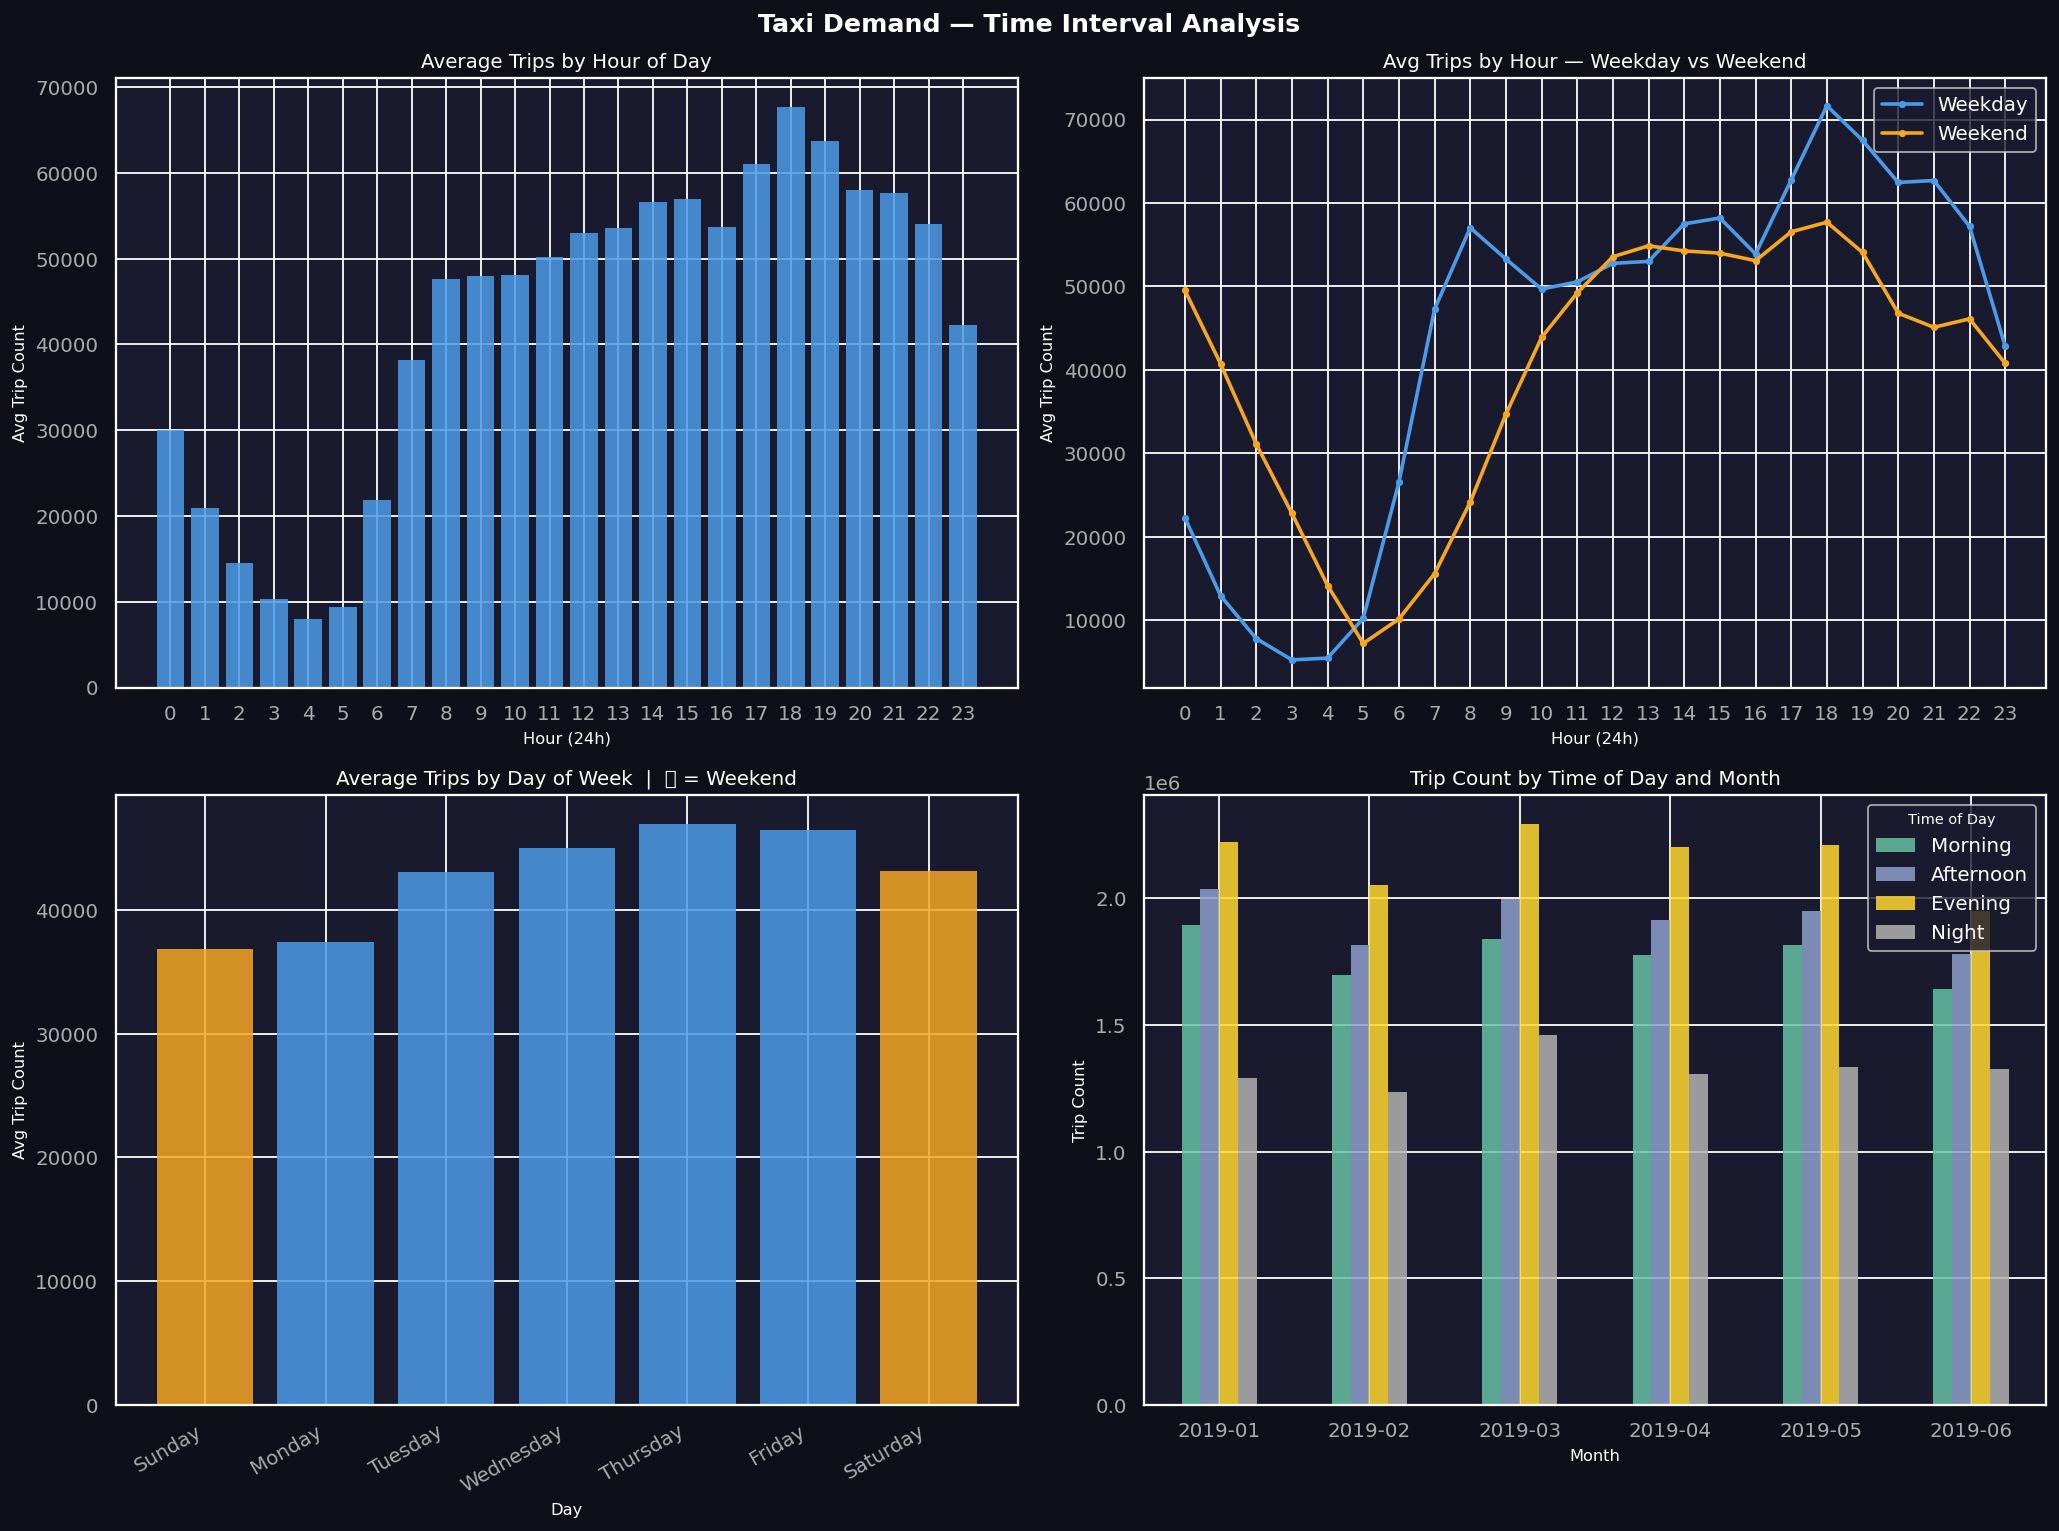

  Saved: 02_demand_time_intervals.png



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — Demand trends by time interval
# ══════════════════════════════════════════════════════════════════════════════
# Why: Time-based demand patterns are core features for your prediction model.
# Identifying hour-of-day, day-of-week and monthly patterns also gives you
# baseline seasonality to compare against when measuring drift.

print("── Section 2: Demand Trends by Time Interval ───────────────────────────")

df_time = con.execute("""
    SELECT
        file_month,
        HOUR(tpep_pickup_datetime)                              AS hour_of_day,
        DAYOFWEEK(tpep_pickup_datetime)                         AS day_of_week,  -- 0=Sun, 6=Sat
        DAYNAME(tpep_pickup_datetime)                           AS day_name,
        CASE
            WHEN DAYOFWEEK(tpep_pickup_datetime) IN (0, 6) THEN 'Weekend'
            ELSE 'Weekday'
        END                                                     AS day_type,
        CASE
            WHEN HOUR(tpep_pickup_datetime) BETWEEN 6  AND 11 THEN 'Morning'
            WHEN HOUR(tpep_pickup_datetime) BETWEEN 12 AND 16 THEN 'Afternoon'
            WHEN HOUR(tpep_pickup_datetime) BETWEEN 17 AND 21 THEN 'Evening'
            ELSE 'Night'
        END                                                     AS time_of_day,
        COUNT(*)                                                AS trip_count
    FROM staging_taxi_trips
    WHERE trip_distance      BETWEEN 0.1 AND 50
    AND trip_duration_mins BETWEEN 1   AND 150
    GROUP BY ALL
    ORDER BY file_month, hour_of_day
""").fetchdf()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Taxi Demand — Time Interval Analysis", fontsize=14,
             fontweight="bold", color="white")

# Hour of day — averaged across all months
ax = axes[0, 0]
df_hourly = df_time.groupby("hour_of_day")["trip_count"].mean().reset_index()
ax.bar(df_hourly["hour_of_day"], df_hourly["trip_count"],
       color="#4C9BE8", alpha=0.85, edgecolor="none")
ax.set_title("Average Trips by Hour of Day")
ax.set_xlabel("Hour (24h)")
ax.set_ylabel("Avg Trip Count")
ax.set_xticks(range(0, 24))

# Hour of day — split by weekday vs weekend
ax = axes[0, 1]
df_hourly_type = df_time.groupby(["hour_of_day", "day_type"])["trip_count"].mean().reset_index()
for day_type, color in [("Weekday", "#4C9BE8"), ("Weekend", "#F5A623")]:
    subset = df_hourly_type[df_hourly_type["day_type"] == day_type]
    ax.plot(subset["hour_of_day"], subset["trip_count"],
            label=day_type, color=color, linewidth=2, marker="o", markersize=3)
ax.set_title("Avg Trips by Hour — Weekday vs Weekend")
ax.set_xlabel("Hour (24h)")
ax.set_ylabel("Avg Trip Count")
ax.set_xticks(range(0, 24))
ax.legend(facecolor="#1a1a2e", labelcolor="white")

# Day of week
ax = axes[1, 0]
day_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
df_daily = df_time.groupby("day_name")["trip_count"].mean().reindex(day_order).reset_index()
colors = ["#F5A623" if d in ["Saturday", "Sunday"] else "#4C9BE8" for d in day_order]
ax.bar(df_daily["day_name"], df_daily["trip_count"], color=colors, alpha=0.85, edgecolor="none")
ax.set_title("Average Trips by Day of Week  |  🟡 = Weekend")
ax.set_xlabel("Day")
ax.set_ylabel("Avg Trip Count")
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

# Time of day bucket by month
ax = axes[1, 1]
tod_order = ["Morning", "Afternoon", "Evening", "Night"]
df_tod = df_time.groupby(["file_month", "time_of_day"])["trip_count"].sum().reset_index()
df_tod_pivot = df_tod.pivot(index="file_month", columns="time_of_day", values="trip_count")
df_tod_pivot = df_tod_pivot[tod_order]
df_tod_pivot.plot(kind="bar", ax=ax, colormap="Set2", alpha=0.85, edgecolor="none")
ax.set_title("Trip Count by Time of Day and Month")
ax.set_xlabel("Month")
ax.set_ylabel("Trip Count")
ax.legend(title="Time of Day", facecolor="#1a1a2e", labelcolor="white",
          title_fontsize=8)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_demand_time_intervals.png",
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("  Saved: 02_demand_time_intervals.png\n")


The charts above show that there is a higher demand for taxi from 5-7pm, which is when people leave from work. This is potentially why afternoons and evenings are of higher demand.

Furthermore, demand increases towards the end of the weekday, when the highest taxi demand in on Friday.

### Understanding demand distribution across NYC boroughs.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — Demand by borough
# ══════════════════════════════════════════════════════════════════════════════
# Why: Location is one of your three core features. Borough-level demand
# patterns reveal spatial concentration of trips and help identify
# which zones are most important for your model.
#
# NOTE: EWR (Newark Airport) is technically outside NYC — treated separately.
# Source: https://d37ci6vzurychx.cloudfront.net/misc/taxi+_zone_lookup.csv

print("── Section 3: Demand by Borough ────────────────────────────────────────")

# Load taxi zone lookup
df_zones = pd.read_csv(ZONE_LOOKUP_PATH)
df_zones.columns = df_zones.columns.str.lower().str.strip()
# Expected columns: locationid, borough, zone, service_zone
print(f"  Zone lookup loaded: {len(df_zones)} zones")
print(f"  Boroughs: {df_zones['borough'].unique()}")

# Register as DuckDB view so we can join in SQL
con.register("taxi_zones", df_zones)

df_borough = con.execute("""
    SELECT
        t.file_month,
        z.borough                           AS pickup_borough,
        COUNT(*)                            AS trip_count,
        ROUND(AVG(t.trip_distance), 2)      AS avg_distance,
        ROUND(AVG(t.trip_duration_mins), 2) AS avg_duration,
        ROUND(AVG(t.fare_amount), 2)        AS avg_fare
    FROM staging_taxi_trips t
    LEFT JOIN taxi_zones z ON t.PULocationID = z.locationid
    WHERE z.borough != 'EWR'   -- Newark airport excluded — outside NYC
    AND trip_distance      BETWEEN 0.1 AND 50
    AND trip_duration_mins BETWEEN 1   AND 150
    GROUP BY t.file_month, z.borough
    ORDER BY t.file_month, trip_count DESC
""").fetchdf()

print("\n  Trip counts by borough:")
display(df_borough)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Taxi Demand by Borough", fontsize=14, fontweight="bold", color="white")

# Trip count by borough per month
ax = axes[0]
df_bor_pivot = df_borough.pivot(index="pickup_borough",
                                columns="file_month",
                                values="trip_count")
df_bor_pivot.plot(kind="bar", ax=ax, colormap="Set2", alpha=0.85, edgecolor="none")
ax.set_title("Trip Count by Borough and Month")
ax.set_xlabel("Borough")
ax.set_ylabel("Trip Count")
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend(title="Month", facecolor="#1a1a2e", labelcolor="white")

# Average fare by borough
ax = axes[1]
df_fare_bor = df_borough.groupby("pickup_borough")["avg_fare"].mean().sort_values(ascending=False)
ax.barh(df_fare_bor.index, df_fare_bor.values, color="#A78BFA", alpha=0.85, edgecolor="none")
ax.set_title("Average Fare by Borough")
ax.set_xlabel("Average Fare ($)")
ax.set_ylabel("Borough")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_demand_by_borough.png",
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("  Saved: 03_demand_by_borough.png\n")


# Top 10 pickup zones overall
df_top_zones = con.execute("""
    SELECT
        z.zone                              AS pickup_zone,
        z.borough,
        COUNT(*)                            AS trip_count
    FROM staging_taxi_trips t
    LEFT JOIN taxi_zones z ON t.PULocationID = z.locationid
    WHERE z.borough != 'EWR'
    AND trip_distance      BETWEEN 0.1 AND 50
    AND trip_duration_mins BETWEEN 1   AND 150
    GROUP BY z.zone, z.borough
    ORDER BY trip_count DESC
    LIMIT 10
""").fetchdf()

print("  Top 10 pickup zones:")
display(df_top_zones)